<a href="https://colab.research.google.com/github/pineapple-666/Veritus-Augustin-Hackathon/blob/main/Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [171]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
seaborn.set()
from sklearn.linear_model import LinearRegression
from scipy import stats  # for mode

In [172]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [173]:
staff_path = '/content/drive/My Drive/MESA/AI/Veritus/Staff_Survey_anonymized.csv'
staff = pd.read_csv(staff_path, header=0).drop(['StartDate', 'EndDate', 'Progress', 'Duration (in seconds)', 'RecordedDate'], axis=1)
staff.head(5)

,Finished,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q2.3_1,...,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5
0,Finished,"How important are the following aspects for promoting Augustin College to future students?* - Flexible learning Options (e.g., online, evening, hybrid)",How important are the following aspects for promoting Augustin College to future students?* - Career-focused programs aligned with workforce needs,How important are the following aspects for promoting Augustin College to future students?* - Competitive tuition and robust financial aid support,How important are the following aspects for promoting Augustin College to future students?* - Mission-driven education rooted in purpose and service,How important are the following aspects for promoting Augustin College to future students?* - Personalized support and a student-centered community,How important are the following aspects for promoting Augustin College to future students?* - Accelerated or modular degree completion pathways,How important are the following aspects for promoting Augustin College to future students?* - Strong Veritus Imperial University reputation and alumni network,How important are the following aspects for promoting Augustin College to future students?* - Strong faculty with industry experience,What should Augustin College actively seek to enroll more of in the future? Please rank the following options by dragging the selection up or down in your preferred rank order where number 1 is the most important option to seek more of and 7 is the lowest. - Working professionals seeking to advance in their current field,...,How important should each of the following ideas be in shaping the future mission of Augustin College? - Preparing students to be ethical leaders in a complex world,"How important should each of the following ideas be in shaping the future mission of Augustin College? - Promoting diversity, inclusion, and equity across the student experience",How important should each of the following ideas be in shaping the future mission of Augustin College? - Focusing on real-world impact and professional advancement,How important should each of the following ideas be in shaping the future mission of Augustin College? - Supporting lifelong learning and career reinvention,How important should each of the following ideas be in shaping the future mission of Augustin College? - Fostering a strong sense of community and personal connection,"How important should each of the following ideas be in shaping the future mission of Augustin College? - Developing student's ability to lead, serve, and transform society",How important should each of the following ideas be in shaping the future mission of Augustin College? - Aligning with the evolving challenges and opportunities of the future workforce,Are there any other ideas or priorities you believe Augustin College should incorporate into its future mission?,"As you look ahead, how can Augustin College better support you in your role as a staff member?","Looking forward, how can Augustin College cultivate a stronger sense of community among the staff?"
1,"{""ImportId"":""finished""}","{""ImportId"":""QID21_1""}","{""ImportId"":""QID21_2""}","{""ImportId"":""QID21_3""}","{""ImportId"":""QID21_4""}","{""ImportId"":""QID21_5""}","{""ImportId"":""QID21_6""}","{""ImportId"":""QID21_7""}","{""ImportId"":""QID21_8""}","{""ImportId"":""QID45_1""}",...,"{""ImportId"":""QID39_3""}","{""ImportId"":""QID39_4""}","{""ImportId"":""QID39_5""}","{""ImportId"":""QID39_6""}","{""ImportId"":""QID39_7""}","{""ImportId"":""QID39_8""}","{""ImportId"":""QID39_9""}","{""ImportId"":""QID40_TEXT""}","{""ImportId"":""QID46_TEXT""}","{""ImportId"":""QID47_TEXT""}"
2,TRUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TRUE,Extremely important,Extremely important,Extremely important,Moderately Important,Very important,Moderately Important,Very important,Moderately Imp

In [174]:
faculty_path = '/content/drive/My Drive/MESA/AI/Veritus/Faculty_Survey_anonymized.csv'
faculty = pd.read_csv(faculty_path, header=0).drop(['StartDate', 'EndDate', 'Progress', 'Duration (in seconds)', 'RecordedDate'], axis=1)
faculty.head(5)

,Finished,Q1.3,Q1.4,Q1.5,Q1.6,Q1.7,Q1.8,Q2.2_1,Q2.2_2,Q2.2_3,...,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5,Q5.6
0,Finished,What is your gender?,What is your race/ethnicity?,How many years have you been teaching for Augustin College?,What Augustin College programs do you teach in?,Which undergraduate programs do you currently teach in?,Which graduate programs do you currently teach in?,"How important are the following aspects for promoting Augustin College to future students?* - Flexible learning Options (e.g., online, evening, hybrid)",How important are the following aspects for promoting Augustin College to future students?* - Career-focused programs aligned with workforce needs,How important are the following aspects for promoting Augustin College to future students?* - Competitive tuition and robust financial aid support,...,"How important should each of the following ideas be in shaping the future mission of Augustin College? - Promoting diversity, inclusion, and equity across the student experience",How important should each of the following ideas be in shaping the future mission of Augustin College? - Focusing on real-world impact and professional advancement,How important should each of the following ideas be in shaping the future mission of Augustin College? - Supporting lifelong learning and career reinvention,How important should each of the following ideas be in shaping the future mission of Augustin College? - Fostering a strong sense of community and personal connection,"How important should each of the following ideas be in shaping the future mission of Augustin College? - Developing student's ability to lead, serve, and transform society",How important should each of the following ideas be in shaping the future mission of Augustin College? - Aligning with the evolving challenges and opportunities of the future workforce,Are there any other ideas or priorities you believe Augustin College should incorporate into its future mission?,How can Augustin College support you better in your teaching in the future?,How can Augustin College cultivate a stronger sense of community among the faculty in the future?,"In the future, how can Augustin College cultivate a stronger sense of community and shared identify among faculty, staff, and students?"
1,"{""ImportId"":""finished""}","{""ImportId"":""QID1""}","{""ImportId"":""QID5""}","{""ImportId"":""QID10_TEXT""}","{""ImportId"":""QID15""}","{""ImportId"":""QID17""}","{""ImportId"":""QID44""}","{""ImportId"":""QID21_1""}","{""ImportId"":""QID21_2""}","{""ImportId"":""QID21_3""}",...,"{""ImportId"":""QID39_4""}","{""ImportId"":""QID39_5""}","{""ImportId"":""QID39_6""}","{""ImportId"":""QID39_7""}","{""ImportId"":""QID39_8""}","{""ImportId"":""QID39_9""}","{""ImportId"":""QID40_TEXT""}","{""ImportId"":""QID46_TEXT""}","{""ImportId"":""QID47_TEXT""}","{""ImportId"":""QID48_TEXT""}"
2,TRUE,Female,Asian,1,Undergraduate Programs,Undergrad Program 1,NaN,Very important,Extremely important,Very important,...,Very important,Very important,Very important,Very important,Very important,Very important,Importance of environmental sustainability and tech-for-good.,Better career advancement,Organize more team building events,Organize more team building events
3,TRUE,Female,White,4,Graduate Programs,NaN,Graduate Program 1,Very important,Extremely important,Extremely important,...,Moderately important,Very important,Very important,Very important,Very important,Extremely important,NaN,NaN,NaN,NaN
4,TRUE,Male,White,8,Undergraduate Programs,Undergrad Program 2,NaN,Very important,Very important,Extremely important,...,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important,NaN,NaN,NaN,NaN


In [175]:
student_path = '/content/drive/My Drive/MESA/AI/Veritus/Student_Survey_anonymized.csv'
# Try common encodings
student = pd.read_csv(student_path, encoding='ISO-8859-1', header=0).drop(['Progress', 'Duration (in seconds)'], axis=1)
faculty.head(5)


,Finished,Q1.3,Q1.4,Q1.5,Q1.6,Q1.7,Q1.8,Q2.2_1,Q2.2_2,Q2.2_3,...,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5,Q5.6
0,Finished,What is your gender?,What is your race/ethnicity?,How many years have you been teaching for Augustin College?,What Augustin College programs do you teach in?,Which undergraduate programs do you currently teach in?,Which graduate programs do you currently teach in?,"How important are the following aspects for promoting Augustin College to future students?* - Flexible learning Options (e.g., online, evening, hybrid)",How important are the following aspects for promoting Augustin College to future students?* - Career-focused programs aligned with workforce needs,How important are the following aspects for promoting Augustin College to future students?* - Competitive tuition and robust financial aid support,...,"How important should each of the following ideas be in shaping the future mission of Augustin College? - Promoting diversity, inclusion, and equity across the student experience",How important should each of the following ideas be in shaping the future mission of Augustin College? - Focusing on real-world impact and professional advancement,How important should each of the following ideas be in shaping the future mission of Augustin College? - Supporting lifelong learning and career reinvention,How important should each of the following ideas be in shaping the future mission of Augustin College? - Fostering a strong sense of community and personal connection,"How important should each of the following ideas be in shaping the future mission of Augustin College? - Developing student's ability to lead, serve, and transform society",How important should each of the following ideas be in shaping the future mission of Augustin College? - Aligning with the evolving challenges and opportunities of the future workforce,Are there any other ideas or priorities you believe Augustin College should incorporate into its future mission?,How can Augustin College support you better in your teaching in the future?,How can Augustin College cultivate a stronger sense of community among the faculty in the future?,"In the future, how can Augustin College cultivate a stronger sense of community and shared identify among faculty, staff, and students?"
1,"{""ImportId"":""finished""}","{""ImportId"":""QID1""}","{""ImportId"":""QID5""}","{""ImportId"":""QID10_TEXT""}","{""ImportId"":""QID15""}","{""ImportId"":""QID17""}","{""ImportId"":""QID44""}","{""ImportId"":""QID21_1""}","{""ImportId"":""QID21_2""}","{""ImportId"":""QID21_3""}",...,"{""ImportId"":""QID39_4""}","{""ImportId"":""QID39_5""}","{""ImportId"":""QID39_6""}","{""ImportId"":""QID39_7""}","{""ImportId"":""QID39_8""}","{""ImportId"":""QID39_9""}","{""ImportId"":""QID40_TEXT""}","{""ImportId"":""QID46_TEXT""}","{""ImportId"":""QID47_TEXT""}","{""ImportId"":""QID48_TEXT""}"
2,TRUE,Female,Asian,1,Undergraduate Programs,Undergrad Program 1,NaN,Very important,Extremely important,Very important,...,Very important,Very important,Very important,Very important,Very important,Very important,Importance of environmental sustainability and tech-for-good.,Better career advancement,Organize more team building events,Organize more team building events
3,TRUE,Female,White,4,Graduate Programs,NaN,Graduate Program 1,Very important,Extremely important,Extremely important,...,Moderately important,Very important,Very important,Very important,Very important,Extremely important,NaN,NaN,NaN,NaN
4,TRUE,Male,White,8,Undergraduate Programs,Undergrad Program 2,NaN,Very important,Very important,Extremely important,...,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important,NaN,NaN,NaN,NaN


In [176]:
student = pd.read_csv(student_path, encoding='ISO-8859-1')
student_cleaned = student.drop(index=[0, 1]).reset_index(drop=True)
student_cleaned.head()

,Progress,Duration (in seconds),Finished,Q1.3,Q1.4,Q1.5,Q1.6,Q1.7,Q1.8,Q1.9,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3
0,100,84,TRUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100,795,TRUE,Female,21,No,White,Yes,No,No,...,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important,NaN
2,100,832,TRUE,Male,19,No,Hispanic or Latino,No,No,No,...,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,NaN
3,100,736,TRUE,Male,43,No,White,Yes,No,No,...,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,NaN
4,100,300,TRUE,Male,35,No,Asian,No,No,No,...,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,NaN


In [177]:
# Select all columns that match your desired ranges
cols_to_keep = (
    [f'Q2.2_{i}' for i in range(1, 9)] +     # Q2.2_1 to Q2.2_8
    [f'Q3.7_{i}' for i in range(1, 6)] +     # Q3.7_1 to Q3.7_5
    [f'Q4.6_{i}' for i in range(1, 9)] +     # Q4.6_1 to Q4.6_8
    [f'Q5.2_{i}' for i in range(1, 10)]      # Q5.2_1 to Q5.2_9
)

# Filter your DataFrame
student_subset = student_cleaned[cols_to_keep]

# Preview result
student_subset.head()


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q3.7_1,Q3.7_2,...,Q4.6_8,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Moderately Important,Very important,Very important,Very important,Moderately Important,Moderately Important,Very important,Very important,Moderately important,Moderately important,...,Very important,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important
2,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,...,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important
3,Extremely important,Very important,Very important,Moderately Important,Very important,Extremely important,Extremely important,Extremely important,Very important,Very important,...,Extremely important,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important
4,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Moderately important,...,Very important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important


In [178]:
student_subset.shape

(220, 30)

In [179]:
student_subset.dtypes

,0
Q2.2_1,object
Q2.2_2,object
Q2.2_3,object
Q2.2_4,object
Q2.2_5,object
Q2.2_6,object
Q2.2_7,object
Q2.2_8,object
Q3.7_1,object
Q3.7_2,object


In [180]:
student_subset['dataset'] = 'student'
student_subset.head()

/tmp/ipython-input-1603133406.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_subset['dataset'] = 'student'


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q3.7_1,Q3.7_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,student
1,Moderately Important,Very important,Very important,Very important,Moderately Important,Moderately Important,Very important,Very important,Moderately important,Moderately important,...,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important,student
2,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,...,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
3,Extremely important,Very important,Very important,Moderately Important,Very important,Extremely important,Extremely important,Extremely important,Very important,Very important,...,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
4,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Moderately important,...,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,student


In [181]:
satff = pd.read_csv(staff_path)
staff_cleaned = staff.drop(index=[0, 1]).reset_index(drop=True)
staff_cleaned.head()

,Finished,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q2.3_1,...,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5
0,TRUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TRUE,Extremely important,Extremely important,Extremely important,Moderately Important,Very important,Moderately Important,Very important,Moderately Important,4,...,Moderately important,Extremely important,Extremely important,Moderately important,Very important,Moderately important,Extremely important,NaN,NaN,NaN
2,TRUE,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Extremely important,1,...,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,NaN,"Increase emphasis on policy and procedure intergradation to increase standardization around programs, staff, faculty, and students.",Streamline communication with all staff members regarding new programs and changes around the college.
3,TRUE,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,1,...,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Very important,"More hands-on opportunities for community engagement, service, and leadership.","Please continue the good transparency, communication, and appreciation I've experienced over the past year.","I think we should continue doing the kinds of college-wide community building we've done this past year. For example, the retreat was energizing and the upcoming cruise is exciting. The time together need not be expensive or extensive ~ the point is to continue coming together so we know one another better and, ultimately, feel a sense of shared purpose in working together."
4,FALSE,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Very important,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [182]:
staff.shape

(22, 95)

In [183]:
# Select all columns that match your desired ranges
cols_to_keep = (
    [f'Q2.2_{i}' for i in range(1, 9)] +     # Q2.2_1 to Q2.2_8
    [f'Q3.7_{i}' for i in range(1, 6)] +     # Q3.7_1 to Q3.7_5
    [f'Q4.6_{i}' for i in range(1, 9)] +     # Q4.6_1 to Q4.6_8
    [f'Q5.2_{i}' for i in range(1, 10)]      # Q5.2_1 to Q5.2_9
)

# Filter your DataFrame
staff_subset = staff_cleaned[cols_to_keep]

# Preview result
staff_subset.head()

,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q3.7_1,Q3.7_2,...,Q4.6_8,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Extremely important,Extremely important,Extremely important,Moderately Important,Very important,Moderately Important,Very important,Moderately Important,Extremely important,Extremely important,...,Extremely important,Moderately important,Extremely important,Moderately important,Extremely important,Extremely important,Moderately important,Very important,Moderately important,Extremely important
2,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,...,Extremely important,Moderately important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important
3,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,Extremely important,Extremely important,...,Very important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Very important
4,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Very important,Extremely important,Very important,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [184]:
staff_subset.shape
#staff_subset.dtypes

(20, 30)

In [185]:
staff_subset['dataset'] = 'staff'
staff_subset.head()

/tmp/ipython-input-2478255036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staff_subset['dataset'] = 'staff'


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q3.7_1,Q3.7_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,staff
1,Extremely important,Extremely important,Extremely important,Moderately Important,Very important,Moderately Important,Very important,Moderately Important,Extremely important,Extremely important,...,Moderately important,Extremely important,Moderately important,Extremely important,Extremely important,Moderately important,Very important,Moderately important,Extremely important,staff
2,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,...,Moderately important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,staff
3,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,Extremely important,Extremely important,...,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Very important,staff
4,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Very important,Extremely important,Very important,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,staff


In [186]:
faculty = pd.read_csv(faculty_path)
faculty_cleaned = faculty.drop(index=[0, 1]).reset_index(drop=True)
faculty_cleaned.head()

,StartDate,EndDate,Progress,Duration (in seconds),Finished,RecordedDate,Q1.3,Q1.4,Q1.5,Q1.6,...,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5,Q5.6
0,5/8/2025 15:03,5/8/2025 15:14,100,663,TRUE,5/8/2025 15:14,Female,Asian,1,Undergraduate Programs,...,Very important,Very important,Very important,Very important,Very important,Very important,Importance of environmental sustainability and tech-for-good.,Better career advancement,Organize more team building events,Organize more team building events
1,5/8/2025 15:07,5/8/2025 15:14,100,418,TRUE,5/8/2025 15:14,Female,White,4,Graduate Programs,...,Moderately important,Very important,Very important,Very important,Very important,Extremely important,NaN,NaN,NaN,NaN
2,5/8/2025 15:08,5/8/2025 15:20,100,721,TRUE,5/8/2025 15:20,Male,White,8,Undergraduate Programs,...,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important,NaN,NaN,NaN,NaN
3,5/8/2025 15:13,5/8/2025 15:20,100,428,TRUE,5/8/2025 15:21,Female,"American Indian or Alaska Native,White",8,"Undergraduate Programs,Graduate Programs",...,Moderately important,Extremely important,Extremely important,Very important,Very important,Extremely important,NaN,NaN,NaN,NaN
4,5/8/2025 15:17,5/8/2025 15:22,100,305,TRUE,5/8/2025 15:22,Male,White,3,Graduate Programs,...,Slightly important,Very important,Very important,Very important,Very important,Very important,No,All is good right now.,NaN,NaN


In [187]:
faculty.shape

(114, 108)

In [188]:
# Filter your DataFrame
faculty_subset = faculty_cleaned[cols_to_keep]

# Preview result
faculty_subset.head()

,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q3.7_1,Q3.7_2,...,Q4.6_8,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9
0,Very important,Extremely important,Very important,Moderately Important,Very important,Very important,Very important,Extremely important,Extremely important,Extremely important,...,NaN,Not at all important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important
1,Very important,Extremely important,Extremely important,Moderately Important,Very important,Very important,Moderately Important,Extremely important,Very important,Extremely important,...,Extremely important,Moderately important,Very important,Extremely important,Moderately important,Very important,Very important,Very important,Very important,Extremely important
2,Very important,Very important,Extremely important,Moderately Important,Moderately Important,Very important,Very important,Very important,Slightly important,Moderately important,...,Very important,Extremely important,Very important,Very important,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important
3,Extremely important,Extremely important,Very important,Very important,Extremely important,Very important,Extremely important,Very important,Very important,Extremely important,...,Extremely important,Moderately important,Extremely important,Moderately important,Moderately important,Extremely important,Extremely important,Very important,Very important,Extremely important
4,Very important,Extremely important,Very important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,Extremely important,Extremely important,...,Very important,Very important,NaN,Moderately important,Slightly important,Very important,Very important,Very important,Very important,Very important


In [189]:
faculty_subset.shape
#faculty_subset.dtypes

(112, 30)

In [190]:
faculty_subset['dataset'] = 'faculty'
faculty_subset.head()

/tmp/ipython-input-3646259319.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faculty_subset['dataset'] = 'faculty'


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q3.7_1,Q3.7_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,Very important,Extremely important,Very important,Moderately Important,Very important,Very important,Very important,Extremely important,Extremely important,Extremely important,...,Not at all important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,faculty
1,Very important,Extremely important,Extremely important,Moderately Important,Very important,Very important,Moderately Important,Extremely important,Very important,Extremely important,...,Moderately important,Very important,Extremely important,Moderately important,Very important,Very important,Very important,Very important,Extremely important,faculty
2,Very important,Very important,Extremely important,Moderately Important,Moderately Important,Very important,Very important,Very important,Slightly important,Moderately important,...,Extremely important,Very important,Very important,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important,faculty
3,Extremely important,Extremely important,Very important,Very important,Extremely important,Very important,Extremely important,Very important,Very important,Extremely important,...,Moderately important,Extremely important,Moderately important,Moderately important,Extremely important,Extremely important,Very important,Very important,Extremely important,faculty
4,Very important,Extremely important,Very important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,Extremely important,Extremely important,...,Very important,NaN,Moderately important,Slightly important,Very important,Very important,Very important,Very important,Very important,faculty


In [191]:
# Check column names
print("Student columns:", list(student_subset.columns))
print("Faculty columns:", list(faculty_subset.columns))
print("Staff columns:", list(staff_subset.columns))


Student columns: ['Q2.2_1', 'Q2.2_2', 'Q2.2_3', 'Q2.2_4', 'Q2.2_5', 'Q2.2_6', 'Q2.2_7', 'Q2.2_8', 'Q3.7_1', 'Q3.7_2', 'Q3.7_3', 'Q3.7_4', 'Q3.7_5', 'Q4.6_1', 'Q4.6_2', 'Q4.6_3', 'Q4.6_4', 'Q4.6_5', 'Q4.6_6', 'Q4.6_7', 'Q4.6_8', 'Q5.2_1', 'Q5.2_2', 'Q5.2_3', 'Q5.2_4', 'Q5.2_5', 'Q5.2_6', 'Q5.2_7', 'Q5.2_8', 'Q5.2_9', 'dataset']
Faculty columns: ['Q2.2_1', 'Q2.2_2', 'Q2.2_3', 'Q2.2_4', 'Q2.2_5', 'Q2.2_6', 'Q2.2_7', 'Q2.2_8', 'Q3.7_1', 'Q3.7_2', 'Q3.7_3', 'Q3.7_4', 'Q3.7_5', 'Q4.6_1', 'Q4.6_2', 'Q4.6_3', 'Q4.6_4', 'Q4.6_5', 'Q4.6_6', 'Q4.6_7', 'Q4.6_8', 'Q5.2_1', 'Q5.2_2', 'Q5.2_3', 'Q5.2_4', 'Q5.2_5', 'Q5.2_6', 'Q5.2_7', 'Q5.2_8', 'Q5.2_9', 'dataset']
Staff columns: ['Q2.2_1', 'Q2.2_2', 'Q2.2_3', 'Q2.2_4', 'Q2.2_5', 'Q2.2_6', 'Q2.2_7', 'Q2.2_8', 'Q3.7_1', 'Q3.7_2', 'Q3.7_3', 'Q3.7_4', 'Q3.7_5', 'Q4.6_1', 'Q4.6_2', 'Q4.6_3', 'Q4.6_4', 'Q4.6_5', 'Q4.6_6', 'Q4.6_7', 'Q4.6_8', 'Q5.2_1', 'Q5.2_2', 'Q5.2_3', 'Q5.2_4', 'Q5.2_5', 'Q5.2_6', 'Q5.2_7', 'Q5.2_8', 'Q5.2_9', 'dataset']


In [192]:
# Compare column sets
columns_match = (list(student_subset.columns) == list(faculty_subset.columns) == list(staff_subset.columns))
print("Do all three datasets have the same columns?", columns_match)

Do all three datasets have the same columns? True


In [193]:
combined_df = pd.concat([student_subset, faculty_subset, staff_subset], ignore_index=True)
combined_df.head()
#combined_df.shape


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q3.7_1,Q3.7_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,student
1,Moderately Important,Very important,Very important,Very important,Moderately Important,Moderately Important,Very important,Very important,Moderately important,Moderately important,...,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important,student
2,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,...,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
3,Extremely important,Very important,Very important,Moderately Important,Very important,Extremely important,Extremely important,Extremely important,Very important,Very important,...,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
4,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Moderately important,...,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,student


In [194]:
# Step 1: Define mapping dictionary
importance_mapping = {
    'Not at all important': 1,
    'Slightly important': 2,
    'Moderately Important': 3,
    'moderately important': 3,
    'Very important': 4,
    'Extremely important': 5
}

# Step 2: Prepare lowercase mapping for robustness
mapping_lower = {k.lower(): v for k, v in importance_mapping.items()}

# Step 3: Function to map text to number
def map_importance(x):
    if pd.isna(x):
        return x  # keep NaN as is
    x_clean = str(x).strip().lower()  # remove extra spaces and lowercase
    return mapping_lower.get(x_clean, x)  # map if exists, else keep original

# Step 4: Select columns to map (all except the last one)
cols_to_map = combined_df.columns[:-1]

# Step 5: Apply mapping to all selected columns
combined_df[cols_to_map] = combined_df[cols_to_map].applymap(map_importance)

# Step 6: Optional - check unique values per column to verify mapping
for col in cols_to_map:
    print(col, combined_df[col].unique())


Q2.2_1 [nan  3.  4.  5.  2.  1.]
Q2.2_2 [nan  4.  5.  3.  2.  1.]
Q2.2_3 [nan  4.  5.  2.  3.  1.]
Q2.2_4 [nan  4.  3.  5.  2.  1.]
Q2.2_5 [nan  3.  4.  5.  1.  2.]
Q2.2_6 [nan  3.  4.  5.  1.  2.]
Q2.2_7 [nan  4.  5.  2.  3.  1.]
Q2.2_8 [nan  4.  5.  3.  2.  1.]
Q3.7_1 [nan  3.  4.  5.  2.]
Q3.7_2 [nan  3.  4.  5.  2.  1.]
Q3.7_3 [nan  3.  4.  5.  2.  1.]
Q3.7_4 [nan  4.  5.  3.  2.  1.]
Q3.7_5 [nan  4.  5.  3.  2.  1.]
Q4.6_1 [nan  3.  5.  4.  2.  1.]
Q4.6_2 [nan  3.  5.  4.  2.  1.]
Q4.6_3 [nan  3.  5.  4.  2.  1.]
Q4.6_4 [nan  4.  5.  3.  2.  1.]
Q4.6_5 [nan  4.  5.  2.  3.  1.]
Q4.6_6 [nan  4.  5.  2.  3.  1.]
Q4.6_7 [nan  5.  4.  3.  2.  1.]
Q4.6_8 [nan  4.  5.  3.  2.  1.]
Q5.2_1 [nan  3.  4.  2.  5.  1.]
Q5.2_2 [nan  3.  4.  5.  2.  1.]
Q5.2_3 [nan  3.  4.  5.  2.  1.]
Q5.2_4 [nan  4.  3.  1.  5.  2.]
Q5.2_5 [nan  4.  3.  5.  2.  1.]
Q5.2_6 [nan  4.  3.  5.  2.  1.]
Q5.2_7 [nan  5.  4.  3.  2.  1.]
Q5.2_8 [nan  4.  3.  5.  2.  1.]
Q5.2_9 [nan  4.  3.  5.  2.  1.]


/tmp/ipython-input-1727853944.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined_df[cols_to_map] = combined_df[cols_to_map].applymap(map_importance)


In [195]:
desc_stats = {}

for col in cols_to_map:
    data = combined_df[col].dropna()  # exclude NaN
    # Use pandas mode as a safer alternative
    mode_val = data.mode()
    mode_val = mode_val.iloc[0] if not mode_val.empty else None

    desc_stats[col] = {
        'mean': data.mean(),
        'min_value': data.min(),
        'max_value': data.max(),
        '25th_percentile': data.quantile(0.25),
        'median': data.median(),
        '75th_percentile': data.quantile(0.75),
        'mode': mode_val,
        'variance': data.var(),
        'standard_deviation': data.std()
    }

# Convert to DataFrame
desc_stats_df = pd.DataFrame(desc_stats).T.round(2)

# Sort by mean -> median -> mode descending
desc_stats_sorted = desc_stats_df.sort_values(
    by=['mean', 'median', 'mode'],
    ascending=[False, False, False]
)

desc_stats_sorted


,mean,min_value,max_value,25th_percentile,median,75th_percentile,mode,variance,standard_deviation
Q3.7_5,4.45,1.0,5.0,4.0,5.0,5.0,5.0,0.50,0.71
Q3.7_2,4.42,1.0,5.0,4.0,5.0,5.0,5.0,0.52,0.72
Q3.7_1,4.41,2.0,5.0,4.0,5.0,5.0,5.0,0.48,0.69
Q2.2_1,4.40,1.0,5.0,4.0,5.0,5.0,5.0,0.72,0.85
Q2.2_2,4.40,1.0,5.0,4.0,5.0,5.0,5.0,0.58,0.76
Q2.2_8,4.40,1.0,5.0,4.0,5.0,5.0,5.0,0.52,0.72
Q5.2_5,4.39,1.0,5.0,4.0,5.0,5.0,5.0,0.57,0.76
Q4.6_1,4.37,1.0,5.0,4.0,5.0,5.0,5.0,0.66,0.81
Q3.7_4,4.33,1.0,5.0,4.0,5.0,5.0,5.0,0.65,0.81
Q2.2_3,4.30,1.0,5.0,4.0,5.0,5.0,5.0,0.78,0.88


In [196]:
# Get the top 10 questions by mean
top_10_cols = desc_stats_sorted.index[:10].tolist()
# Second row in student dataset contains full question text
# Note: pandas indexing starts at 0, so second row is index 1
second_row = student.iloc[0]
top_10_questions = second_row[top_10_cols]
pd.set_option('display.max_colwidth', None)
top_10_questions


,0
Q3.7_5,How important are the following features for ensuring academic excellence at Augustin College? - Clear and timely feedback
Q3.7_2,How important are the following features for ensuring academic excellence at Augustin College? - Strong support systems
Q3.7_1,How important are the following features for ensuring academic excellence at Augustin College? - High academic standards
Q2.2_1,"How important are the following aspects for promoting Augustin College to future students? - Flexible learning Options (e.g., online, evening, hybrid)"
Q2.2_2,How important are the following aspects for promoting Augustin College to future students? - Career-focused programs aligned with workforce needs
Q2.2_8,How important are the following aspects for promoting Augustin College to future students? - Strong faculty with industry experience
Q5.2_5,How important should each of the following ideas be in shaping the future mission of Augustin College? - Focusing on real-world impact and professional advancement
Q4.6_1,How important are the following priorities for preparing students for life after Augustin College? - Opportunities for career networking
Q3.7_4,How important are the following features for ensuring academic excellence at Augustin College? - Transparent grading
Q2.2_3,How important are the following aspects for promoting Augustin College to future students? - Competitive tuition and robust financial aid support


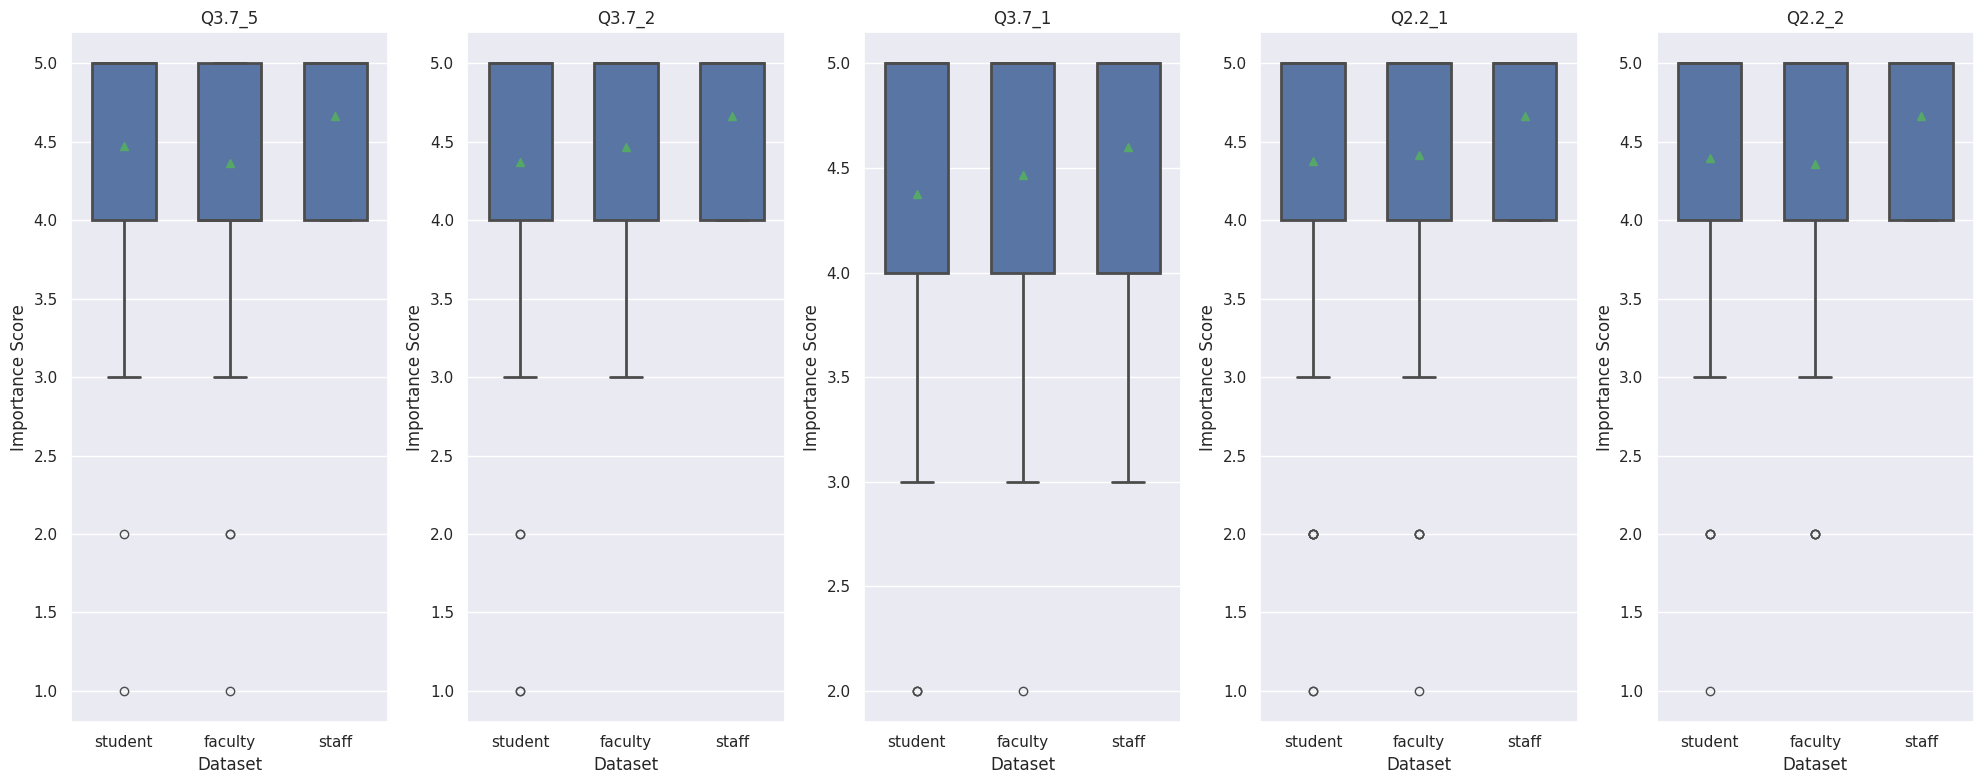

In [200]:
##top 5 columns in stdunt dataset
# Step 1: Select top 5 columns
top_5_cols = desc_stats_sorted.index[:5].tolist()

# Step 2: Include the 'dataset' column for grouping
plot_data = combined_df[top_5_cols + ['dataset']]

# Step 3: Create boxplots for each column
plt.figure(figsize=(20, 8))  # Adjust figure size

for i, col in enumerate(top_5_cols, 1):
    plt.subplot(1, 5, i)  # 1 row, 5 columns of subplots
    sns.boxplot(x='dataset', y=col, data=plot_data, width=0.6, linewidth=2, showmeans=True)
    plt.title(col)
    plt.ylabel('Importance Score')
    plt.xlabel('Dataset')

plt.tight_layout()
plt.show()


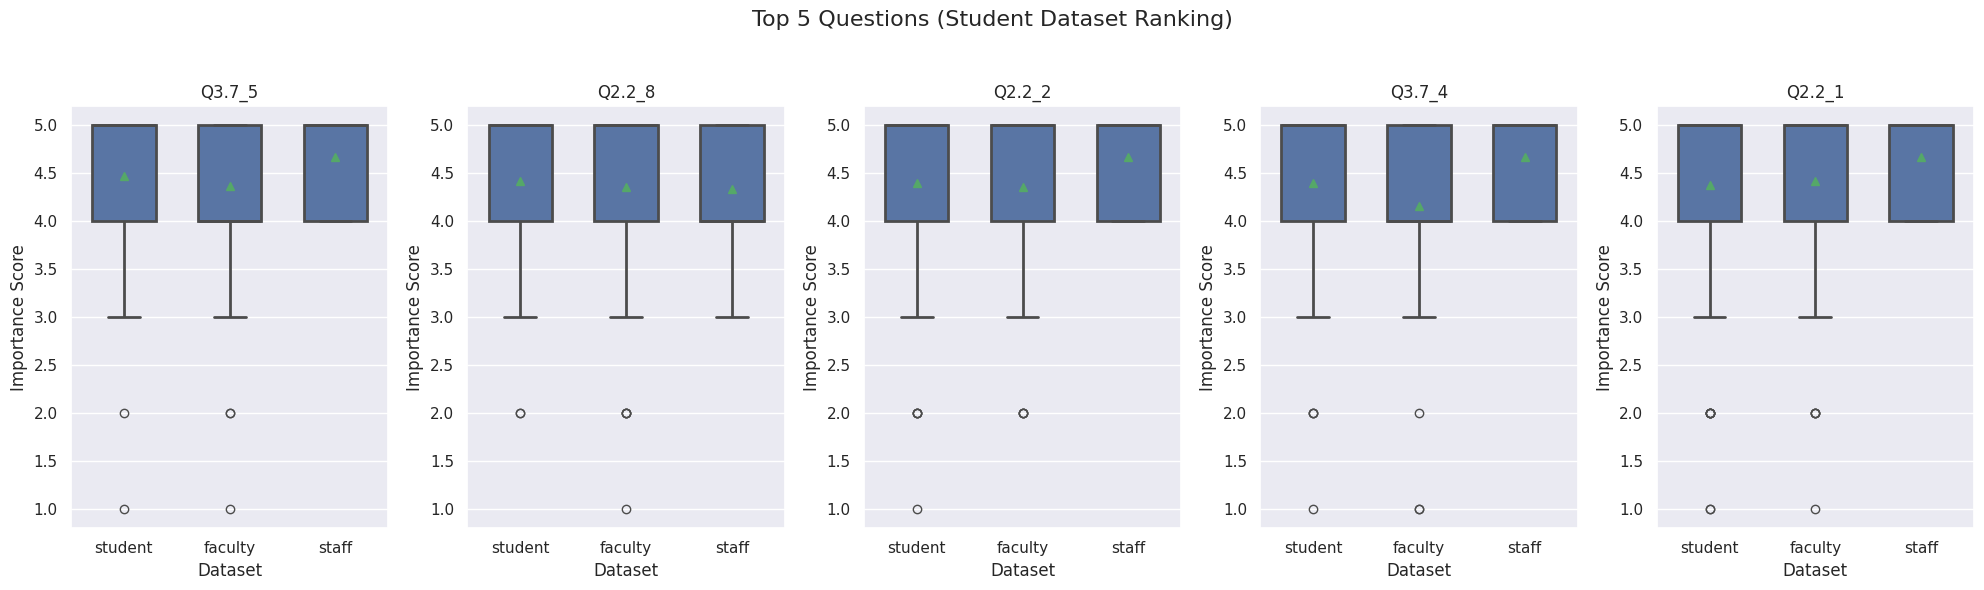

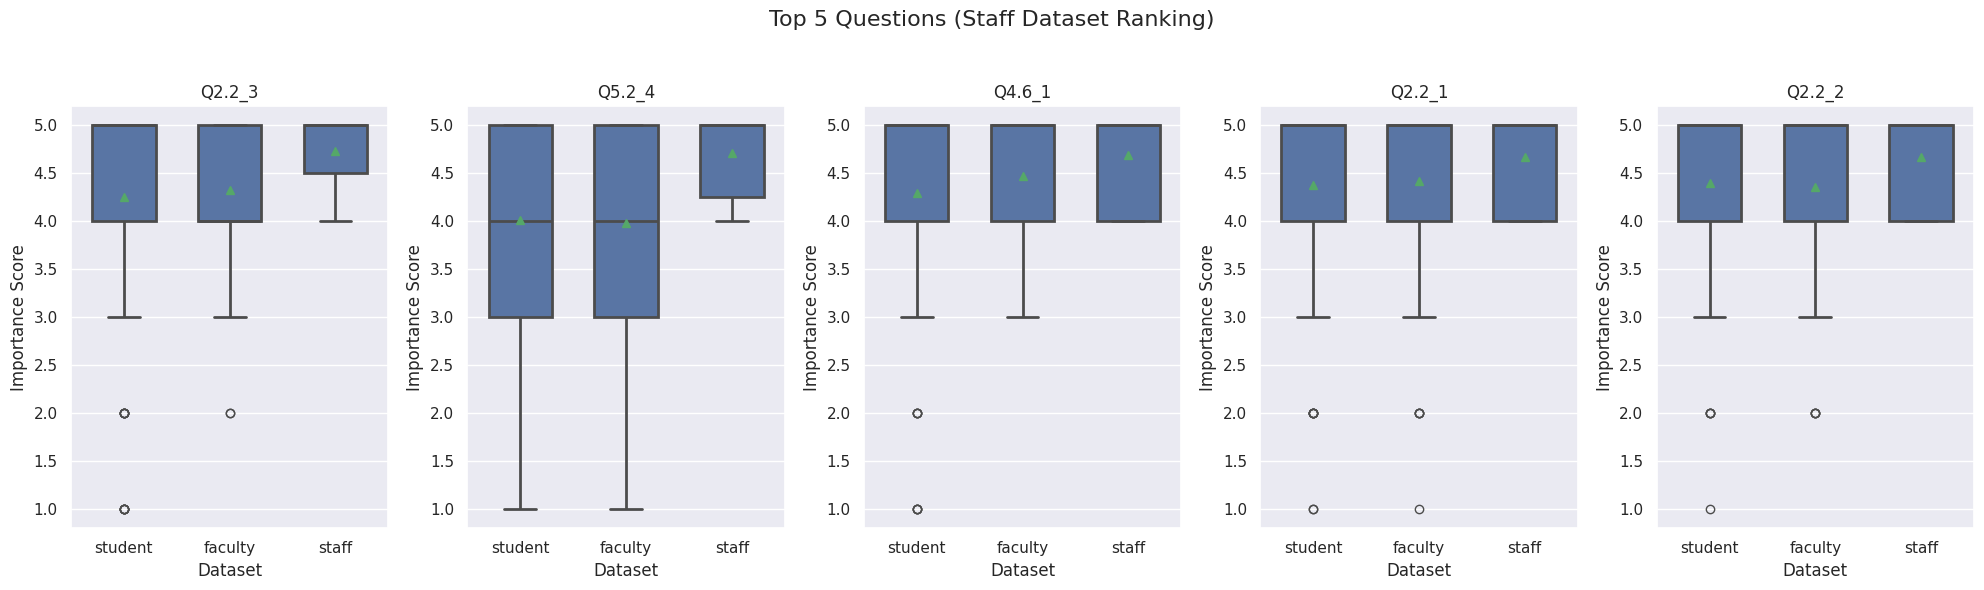

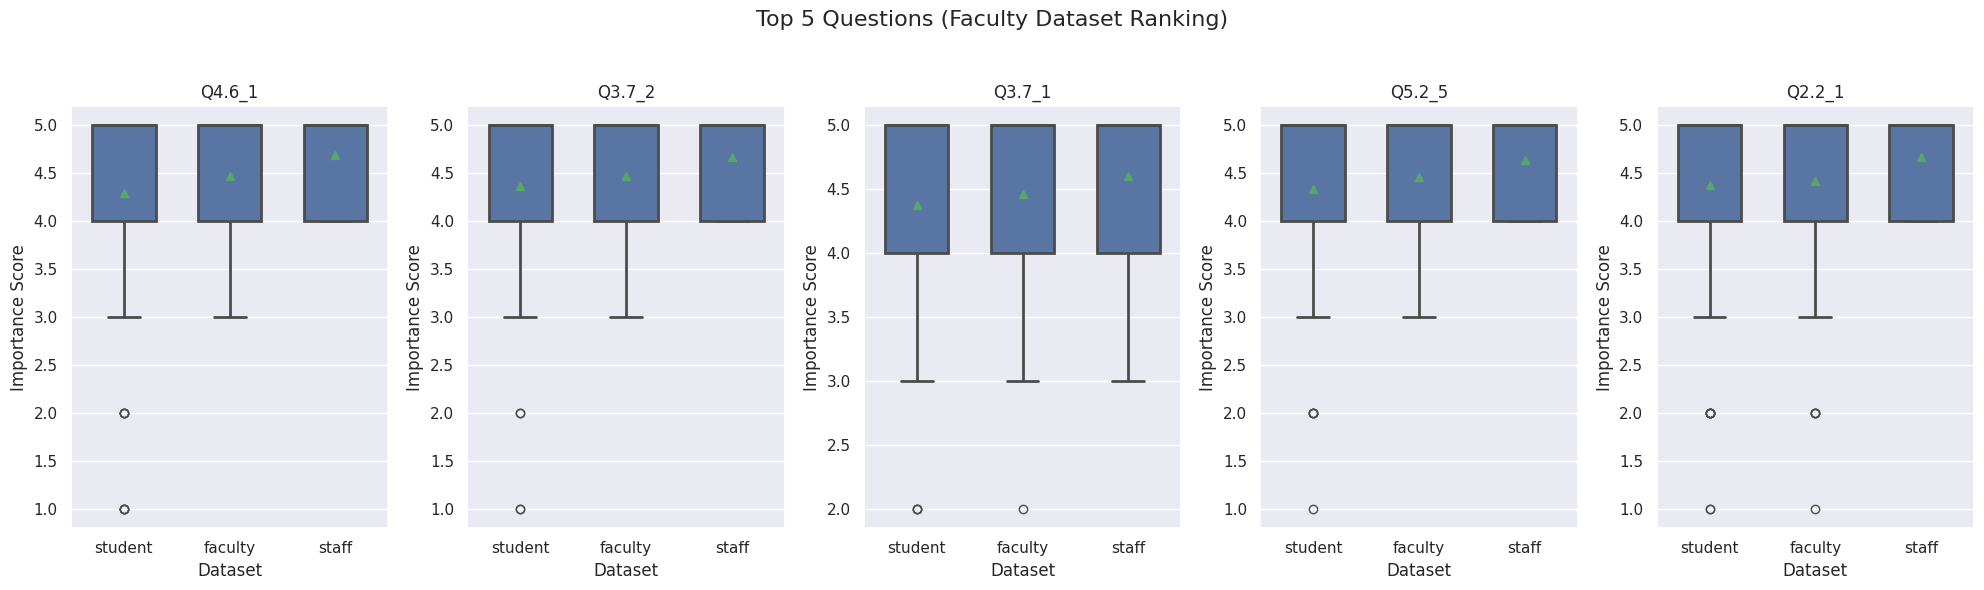

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Function to compute descriptive stats
def compute_desc_stats(df, cols):
    desc_stats = {}
    for col in cols:
        data = df[col].dropna()
        mode_val = data.mode()
        mode_val = mode_val.iloc[0] if not mode_val.empty else None
        desc_stats[col] = {
            'mean': data.mean(),
            'median': data.median(),
            'mode': mode_val,
            'min_value': data.min(),
            'max_value': data.max(),
            '25th_percentile': data.quantile(0.25),
            '75th_percentile': data.quantile(0.75),
            'variance': data.var(),
            'standard_deviation': data.std()
        }
    return pd.DataFrame(desc_stats).T

# Step 2: Select question columns (exclude 'dataset')
cols_to_use = combined_df.columns.drop('dataset')

# Step 3: Compute descriptive stats for each dataset
stats_student = compute_desc_stats(combined_df[combined_df['dataset']=='student'], cols_to_use)
stats_staff = compute_desc_stats(combined_df[combined_df['dataset']=='staff'], cols_to_use)
stats_faculty = compute_desc_stats(combined_df[combined_df['dataset']=='faculty'], cols_to_use)

# Step 4: Select top 5 columns for each dataset based on mean → median → mode descending
top5_student = stats_student.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()
top5_staff   = stats_staff.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()
top5_faculty = stats_faculty.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()

# Step 5: Plot boxplots grouped by dataset
def plot_boxplot(top_cols, title):
    plt.figure(figsize=(20,6))
    for i, col in enumerate(top_cols, 1):
        plt.subplot(1,5,i)
        sns.boxplot(x='dataset', y=col, data=combined_df, width=0.6, linewidth=2, showmeans=True)
        plt.title(col)
        plt.ylabel('Importance Score')
        plt.xlabel('Dataset')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Student top 5
plot_boxplot(top5_student, 'Top 5 Questions (Student Dataset Ranking)')

# Staff top 5
plot_boxplot(top5_staff, 'Top 5 Questions (Staff Dataset Ranking)')

# Faculty top 5
plot_boxplot(top5_faculty, 'Top 5 Questions (Faculty Dataset Ranking)')
